# 1. Librerías y configuración (Predicción Extrema)

Notebook avanzado para predecir los 12 animalitos del día (08:00–19:00) para HOY y MAÑANA. Incluye features cíclicas, lags por hora (sin fuga), dos modelos (RF y XGB con early stopping) y asignación óptima (SciPy) para evitar repeticiones por día.


In [8]:
# Imports y setup
import os
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss

from xgboost import XGBClassifier
from scipy.optimize import linear_sum_assignment

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "resultados_guacharoactivo_completo2.txt"



# 2. Carga y limpieza

Lee el histórico, limpia texto y crea variables calendarias base.


In [9]:
df = pd.read_csv(
    DATA_PATH,
    names=["Fecha", "Hora", "Animal"],
    sep=",",
    dtype={"Fecha": str, "Hora": str, "Animal": str},
)

df["Fecha"] = df["Fecha"].astype(str).str.strip()
df["Hora"] = df["Hora"].astype(str).str.strip()
df["Animal"] = df["Animal"].astype(str).str.strip()

# Tipos fecha/hora
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%Y-%m-%d", errors="coerce")
hora_dt = pd.to_datetime(df["Hora"], format="%I:%M %p", errors="coerce")
df = df.loc[df["Fecha"].notna() & hora_dt.notna()].copy()
df["Hora24"] = hora_dt.dt.hour.astype(int)

df["Año"] = df["Fecha"].dt.year
df["Mes"] = df["Fecha"].dt.month
df["DiaSemana"] = df["Fecha"].dt.dayofweek
df["SemanaISO"] = df["Fecha"].dt.isocalendar().week.astype(int)
df["EsFinde"] = (df["DiaSemana"] >= 5).astype(int)
df["DiaMes"] = df["Fecha"].dt.day

print("Rango de fechas:", df["Fecha"].min().date(), "->", df["Fecha"].max().date())
print("Registros:", len(df))


Rango de fechas: 2022-12-26 -> 2025-10-29
Registros: 12036


# 3. Diccionario de animales

Codificación de etiquetas para el objetivo.


In [10]:
le = LabelEncoder()
df["AnimalId"] = le.fit_transform(df["Animal"].values)
id_to_animal = {i: a for i, a in enumerate(le.classes_)}
print("Clases:", len(le.classes_))



Clases: 78


# 4. Features avanzadas: cíclicas y lags por hora (sin fuga)

- Cíclicas: `sin/cos` de hora, día de semana, mes.
- Lags por hora (mesmo sorteo): animal de D-1, D-2, D-3 en misma hora.
- Evita fuga de información (se construyen con datos previos).


In [11]:
def add_cyclical(df_in: pd.DataFrame) -> pd.DataFrame:
    d = df_in.copy()
    d["sin_hora"] = np.sin(2 * np.pi * d["Hora24"] / 24)
    d["cos_hora"] = np.cos(2 * np.pi * d["Hora24"] / 24)
    d["sin_dow"] = np.sin(2 * np.pi * d["DiaSemana"] / 7)
    d["cos_dow"] = np.cos(2 * np.pi * d["DiaSemana"] / 7)
    d["sin_mes"] = np.sin(2 * np.pi * (d["Mes"] - 1) / 12)
    d["cos_mes"] = np.cos(2 * np.pi * (d["Mes"] - 1) / 12)
    return d

# Lags por hora: animal de días previos en la misma hora (D-1, D-2, D-3)
# Se hace por cada hora 8..19 independientemente (merge por Fecha y Hora24)

def add_hourly_lags(df_in: pd.DataFrame, max_lag: int = 3) -> pd.DataFrame:
    d = df_in.sort_values(["Hora24", "Fecha"]).copy()
    lag_cols = []
    for lag in range(1, max_lag + 1):
        col = f"lag{lag}_same_hour_id"
        d[col] = (
            d.groupby("Hora24")["AnimalId"].shift(lag)
        )
        lag_cols.append(col)
    return d, lag_cols

# Construcción de features
work = df.copy()
work, lag_cols = add_hourly_lags(work, max_lag=3)
work = add_cyclical(work)

FEATURES = [
    "Hora24", "DiaSemana", "Mes", "SemanaISO", "Año", "EsFinde", "DiaMes",
    "sin_hora", "cos_hora", "sin_dow", "cos_dow", "sin_mes", "cos_mes",
] + lag_cols

# Filtrar filas sin NaN en lags (para entrenamiento)
train_mask = work[lag_cols].notna().all(axis=1)
train_df = work.loc[train_mask].copy()

X_all = train_df[FEATURES].astype(float).values
y_all = train_df["AnimalId"].values

print("X_all shape:", X_all.shape, "y_all:", y_all.shape)
print("Features:", FEATURES)


X_all shape: (12000, 16) y_all: (12000,)
Features: ['Hora24', 'DiaSemana', 'Mes', 'SemanaISO', 'Año', 'EsFinde', 'DiaMes', 'sin_hora', 'cos_hora', 'sin_dow', 'cos_dow', 'sin_mes', 'cos_mes', 'lag1_same_hour_id', 'lag2_same_hour_id', 'lag3_same_hour_id']


# 5. Split temporal y entrenamiento con early stopping (XGB)

- Split temporal: usar últimas 14 jornadas como validación.
- RF: entrena en todo el set de train.
- XGB: usa validación para early stopping (rápido y evita sobreajuste).


In [12]:
# Orden temporal por Fecha y Hora para split
train_df = train_df.sort_values(["Fecha", "Hora24"]).reset_index(drop=True)

# Elegimos validación como las últimas 14 jornadas completas (aprox 14*12 filas)
# Si no alcanza, tomamos 7.
unique_days = train_df["Fecha"].dt.date.unique()
val_days = 14 if len(unique_days) > 30 else min(7, len(unique_days)//4)
val_dates = set(unique_days[-val_days:])

val_mask = train_df["Fecha"].dt.date.isin(val_dates)
X_tr, y_tr = train_df.loc[~val_mask, FEATURES].astype(float).values, train_df.loc[~val_mask, "AnimalId"].values
X_val, y_val = train_df.loc[val_mask, FEATURES].astype(float).values, train_df.loc[val_mask, "AnimalId"].values

print("Train:", X_tr.shape, "Val:", X_val.shape)

# Modelos
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

print("Entrenando RF...")
rf.fit(X_tr, y_tr)

# XGBoost con API nativa (compatible con versiones antiguas) y early stopping
import xgboost as xgb_lib
print("Entrenando XGB (xgboost.train) con early stopping...")
dtrain = xgb_lib.DMatrix(X_tr, label=y_tr)
dval = xgb_lib.DMatrix(X_val, label=y_val)
num_class = len(le.classes_)
params = {
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'num_class': int(num_class),
    'max_depth': 6,
    'eta': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 2,
    'lambda': 2.0,
    'tree_method': 'hist',
}
watchlist = [(dval, 'validation')]
xgb_booster = xgb_lib.train(
    params,
    dtrain,
    num_boost_round=1500,
    evals=watchlist,
    early_stopping_rounds=50,
    verbose_eval=False,
)

best_iter = getattr(xgb_booster, 'best_iteration', None)
print("Listo. Best iteration (XGB):", best_iter if best_iter is not None else 'N/A')


Train: (11832, 16) Val: (168, 16)
Entrenando RF...
Entrenando XGB (xgboost.train) con early stopping...
Listo. Best iteration (XGB): 11


# 6. Construcción de entradas para HOY y MAÑANA

Genera 12 filas (08–19) para hoy y mañana, con lags por hora calculados correctamente a partir del histórico (sin fuga).


In [13]:
def build_future_frame(base_df: pd.DataFrame, target_date: datetime.date) -> pd.DataFrame:
    rows = []
    for h in range(8, 20):
        rows.append({
            "Fecha": pd.Timestamp(target_date),
            "Hora24": h,
            "DiaSemana": pd.Timestamp(target_date).dayofweek,
            "Mes": pd.Timestamp(target_date).month,
            "SemanaISO": pd.Timestamp(target_date).isocalendar().week,
            "Año": pd.Timestamp(target_date).year,
            "EsFinde": int(pd.Timestamp(target_date).dayofweek >= 5),
            "DiaMes": pd.Timestamp(target_date).day,
        })
    fut = pd.DataFrame(rows)

    # Para lags por hora, hay que buscar en el histórico la última(s) ocurrencia(s) previas en esa hora
    # Creamos un marco con historial por hora y animal id para hacer shift y luego tomar la última fila anterior a target
    hist = base_df[["Fecha", "Hora24", "AnimalId"]].copy()
    hist = hist[hist["Fecha"] < pd.Timestamp(target_date)].copy()
    hist = hist.sort_values(["Hora24", "Fecha"])  # orden para shift

    tmp, lag_cols = add_hourly_lags(hist, max_lag=3)
    # Al quedarnos con la última observación por hora (previa al target), tomamos los lags ya calculados
    last_per_hour = tmp.groupby("Hora24").tail(1)[["Hora24"] + lag_cols]

    # Merge lags al futuro por Hora24
    fut = fut.merge(last_per_hour, on="Hora24", how="left")

    fut = add_cyclical(fut)
    return fut, lag_cols

hoy = datetime.now().date()
max_data_date = df["Fecha"].max().date()
# Si los datos terminan antes de hoy, igual predecimos hoy y mañana con lo disponible
future_today = hoy
future_tomorrow = hoy + timedelta(days=1)

fut_today, lag_cols_today = build_future_frame(work, future_today)
fut_tomorrow, lag_cols_tomorrow = build_future_frame(work, future_tomorrow)

X_today = fut_today[FEATURES].astype(float).values
X_tomorrow = fut_tomorrow[FEATURES].astype(float).values

print("Hoy:", future_today, "Mañana:", future_tomorrow)
print("Shapes:", X_today.shape, X_tomorrow.shape)


Hoy: 2025-10-30 Mañana: 2025-10-31
Shapes: (12, 16) (12, 16)


# 7. Predicción y asignación Húngara (sin repetición)

Obtiene probabilidades por hora y realiza la asignación óptima 12x78 para HOY y MAÑANA.


In [14]:
def hungarian_assign(proba: np.ndarray, epsilon: float = 1e-9):
    costs = -np.log(np.clip(proba, epsilon, 1.0))
    row_ind, col_ind = linear_sum_assignment(costs)
    return row_ind, col_ind

# Probabilidades hoy/mañana
proba_rf_today = rf.predict_proba(X_today)
proba_rf_tom = rf.predict_proba(X_tomorrow)

# XGBoost (booster) con DMatrix
d_today = xgb_lib.DMatrix(X_today)
d_tom = xgb_lib.DMatrix(X_tomorrow)
proba_xgb_today = xgb_booster.predict(d_today)
proba_xgb_tom = xgb_booster.predict(d_tom)

# Asignación
rows, cols = hungarian_assign(proba_rf_today)
rf_today = [{
    "Fecha": future_today,
    "Hora": f"{h:02d}:00",
    "Animal": id_to_animal[c],
    "Probabilidad": float(proba_rf_today[i, c])
} for i, (h, c) in enumerate(zip(range(8,20), cols))]

rows, cols = hungarian_assign(proba_xgb_today)
xgb_today = [{
    "Fecha": future_today,
    "Hora": f"{h:02d}:00",
    "Animal": id_to_animal[c],
    "Probabilidad": float(proba_xgb_today[i, c])
} for i, (h, c) in enumerate(zip(range(8,20), cols))]

rows, cols = hungarian_assign(proba_rf_tom)
rf_tom = [{
    "Fecha": future_tomorrow,
    "Hora": f"{h:02d}:00",
    "Animal": id_to_animal[c],
    "Probabilidad": float(proba_rf_tom[i, c])
} for i, (h, c) in enumerate(zip(range(8,20), cols))]

rows, cols = hungarian_assign(proba_xgb_tom)
xgb_tom = [{
    "Fecha": future_tomorrow,
    "Hora": f"{h:02d}:00",
    "Animal": id_to_animal[c],
    "Probabilidad": float(proba_xgb_tom[i, c])
} for i, (h, c) in enumerate(zip(range(8,20), cols))]

rf_today_df = pd.DataFrame(rf_today).sort_values("Hora").reset_index(drop=True)
xgb_today_df = pd.DataFrame(xgb_today).sort_values("Hora").reset_index(drop=True)
rf_tom_df = pd.DataFrame(rf_tom).sort_values("Hora").reset_index(drop=True)
xgb_tom_df = pd.DataFrame(xgb_tom).sort_values("Hora").reset_index(drop=True)

rf_today_df.head(), xgb_today_df.head(), rf_tom_df.head(), xgb_tom_df.head()


(        Fecha   Hora      Animal  Probabilidad
 0  2025-10-30  08:00      Jirafa      0.124705
 1  2025-10-30  09:00     Pantera      0.053813
 2  2025-10-30  10:00    Ciempies      0.043710
 3  2025-10-30  11:00  Hipopotamo      0.062790
 4  2025-10-30  12:00       Pulpo      0.077894,
         Fecha   Hora    Animal  Probabilidad
 0  2025-10-30  08:00       Oso      0.032858
 1  2025-10-30  09:00      Toro      0.033602
 2  2025-10-30  10:00  Elefante      0.030633
 3  2025-10-30  11:00   Ballena      0.025068
 4  2025-10-30  12:00   Hormiga      0.034687,
         Fecha   Hora      Animal  Probabilidad
 0  2025-10-31  08:00      Jirafa      0.128590
 1  2025-10-31  09:00     Pantera      0.059363
 2  2025-10-31  10:00    Ciempies      0.061071
 3  2025-10-31  11:00  Hipopotamo      0.054498
 4  2025-10-31  12:00       Pulpo      0.048209,
         Fecha   Hora    Animal  Probabilidad
 0  2025-10-31  08:00       Oso      0.033004
 1  2025-10-31  09:00      Toro      0.044817
 2  202

# 8. Exportación de resultados

Guarda 4 CSVs (RF/XGB para HOY y MAÑANA) y dos comparativos por hora.


In [15]:
# Exportes
p_today = future_today.strftime('%Y%m%d')
p_tom = future_tomorrow.strftime('%Y%m%d')

out_rf_today = BASE_DIR / f"predicciones_extrema_{p_today}_RF.csv"
out_xgb_today = BASE_DIR / f"predicciones_extrema_{p_today}_XGB.csv"
out_rf_tom = BASE_DIR / f"predicciones_extrema_{p_tom}_RF.csv"
out_xgb_tom = BASE_DIR / f"predicciones_extrema_{p_tom}_XGB.csv"

rf_today_df.to_csv(out_rf_today, index=False)
xgb_today_df.to_csv(out_xgb_today, index=False)
rf_tom_df.to_csv(out_rf_tom, index=False)
xgb_tom_df.to_csv(out_xgb_tom, index=False)

cmp_today = pd.DataFrame({
    "Fecha": rf_today_df["Fecha"],
    "Hora": rf_today_df["Hora"],
    "RF_Animal": rf_today_df["Animal"],
    "RF_Prob": rf_today_df["Probabilidad"],
    "XGB_Animal": xgb_today_df["Animal"],
    "XGB_Prob": xgb_today_df["Probabilidad"],
})
out_cmp_today = BASE_DIR / f"comparacion_extrema_{p_today}.csv"
cmp_today.to_csv(out_cmp_today, index=False)

cmp_tom = pd.DataFrame({
    "Fecha": rf_tom_df["Fecha"],
    "Hora": rf_tom_df["Hora"],
    "RF_Animal": rf_tom_df["Animal"],
    "RF_Prob": rf_tom_df["Probabilidad"],
    "XGB_Animal": xgb_tom_df["Animal"],
    "XGB_Prob": xgb_tom_df["Probabilidad"],
})
out_cmp_tom = BASE_DIR / f"comparacion_extrema_{p_tom}.csv"
cmp_tom.to_csv(out_cmp_tom, index=False)

print("Exportado:")
print(out_rf_today)
print(out_xgb_today)
print(out_rf_tom)
print(out_xgb_tom)
print(out_cmp_today)
print(out_cmp_tom)


Exportado:
/home/samuelb/Documentos/python/Inteligencia_Artificial_Uni/Examen Final/Animalitos/predicciones_extrema_20251030_RF.csv
/home/samuelb/Documentos/python/Inteligencia_Artificial_Uni/Examen Final/Animalitos/predicciones_extrema_20251030_XGB.csv
/home/samuelb/Documentos/python/Inteligencia_Artificial_Uni/Examen Final/Animalitos/predicciones_extrema_20251031_RF.csv
/home/samuelb/Documentos/python/Inteligencia_Artificial_Uni/Examen Final/Animalitos/predicciones_extrema_20251031_XGB.csv
/home/samuelb/Documentos/python/Inteligencia_Artificial_Uni/Examen Final/Animalitos/comparacion_extrema_20251030.csv
/home/samuelb/Documentos/python/Inteligencia_Artificial_Uni/Examen Final/Animalitos/comparacion_extrema_20251031.csv


# 9. Visualización y chequeos rápidos

- Mostrar tablas HOY/MAÑANA por modelo.
- Gráfico de probabilidad asignada por hora.


RF HOY


,Fecha,Hora,Animal,Probabilidad
0,2025-10-30,08:00,Jirafa,0.124705
1,2025-10-30,09:00,Pantera,0.053813
2,2025-10-30,10:00,Ciempies,0.043710
3,2025-10-30,11:00,Hipopotamo,0.062790
4,2025-10-30,12:00,Pulpo,0.077894
5,2025-10-30,13:00,Cangrejo,0.047086
6,2025-10-30,14:00,Elefante,0.068861
7,2025-10-30,15:00,Gorila,0.083919
8,2025-10-30,16:00,Tucan,0.088410
9,2025-10-30,17:00,Chiguire,0.060459


XGB HOY


,Fecha,Hora,Animal,Probabilidad
0,2025-10-30,08:00,Oso,0.032858
1,2025-10-30,09:00,Toro,0.033602
2,2025-10-30,10:00,Elefante,0.030633
3,2025-10-30,11:00,Ballena,0.025068
4,2025-10-30,12:00,Hormiga,0.034687
5,2025-10-30,13:00,Cebra,0.025569
6,2025-10-30,14:00,Cochino,0.029850
7,2025-10-30,15:00,Cangrejo,0.026890
8,2025-10-30,16:00,Tigre,0.042116
9,2025-10-30,17:00,Tucan,0.026196


RF MAÑANA


,Fecha,Hora,Animal,Probabilidad
0,2025-10-31,08:00,Jirafa,0.128590
1,2025-10-31,09:00,Pantera,0.059363
2,2025-10-31,10:00,Ciempies,0.061071
3,2025-10-31,11:00,Hipopotamo,0.054498
4,2025-10-31,12:00,Pulpo,0.048209
5,2025-10-31,13:00,Bufalo,0.033981
6,2025-10-31,14:00,Elefante,0.040269
7,2025-10-31,15:00,Gorila,0.072524
8,2025-10-31,16:00,Tucan,0.065548
9,2025-10-31,17:00,Caracol,0.069056


XGB MAÑANA


,Fecha,Hora,Animal,Probabilidad
0,2025-10-31,08:00,Oso,0.033004
1,2025-10-31,09:00,Toro,0.044817
2,2025-10-31,10:00,Elefante,0.029001
3,2025-10-31,11:00,Aguila,0.023076
4,2025-10-31,12:00,Hormiga,0.035482
5,2025-10-31,13:00,Cebra,0.023543
6,2025-10-31,14:00,Tiburon,0.026687
7,2025-10-31,15:00,Puercoespin,0.025919
8,2025-10-31,16:00,Tigre,0.042771
9,2025-10-31,17:00,Tucan,0.029735


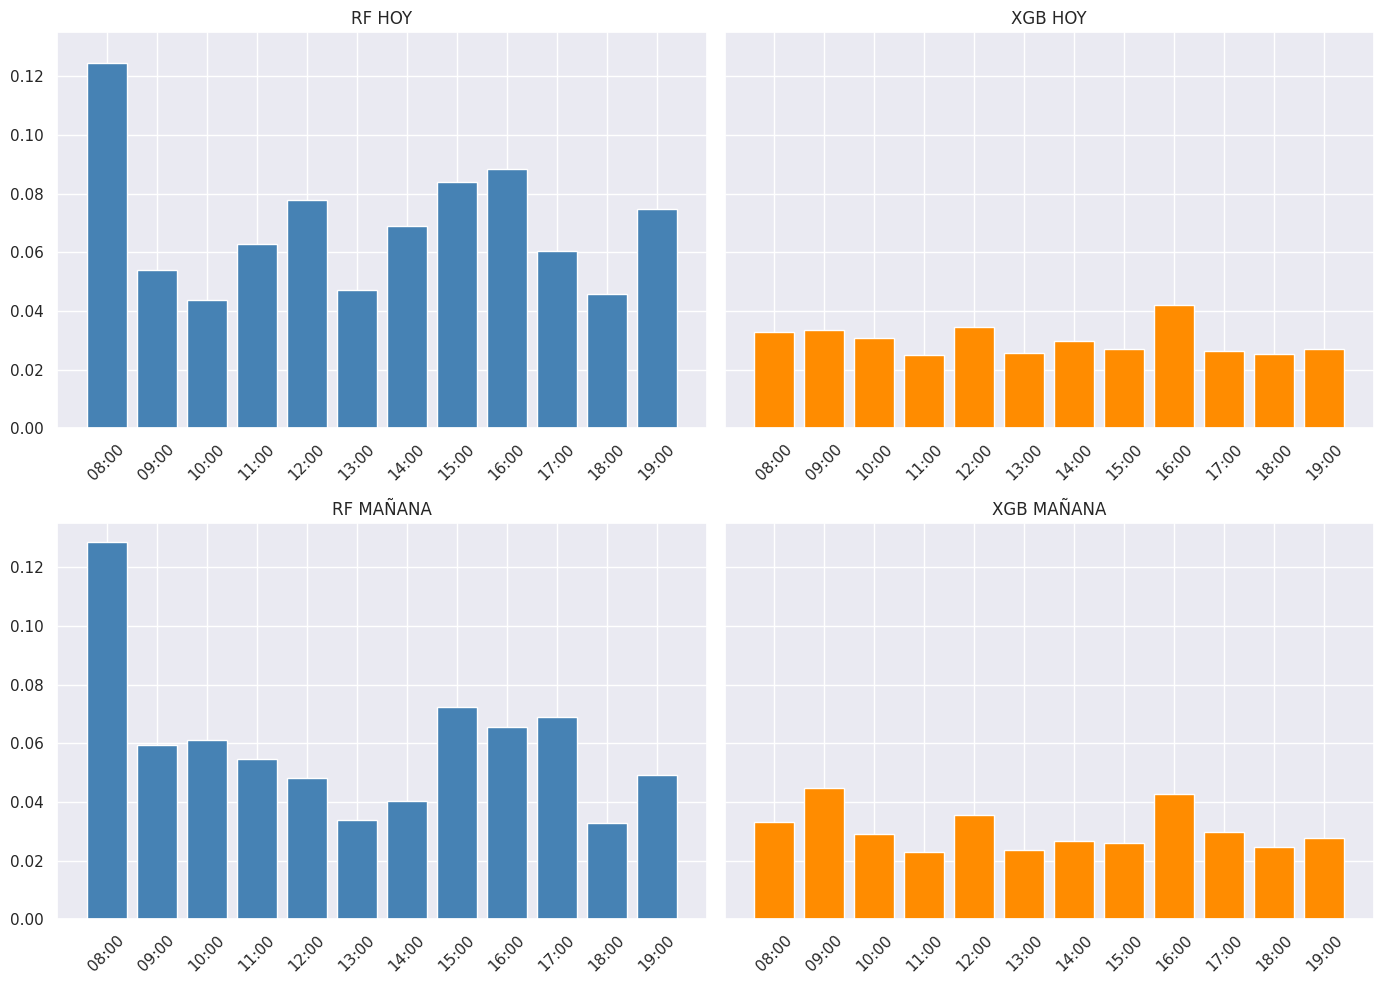

In [16]:
# Tablas
print("RF HOY")
display(rf_today_df)
print("XGB HOY")
display(xgb_today_df)
print("RF MAÑANA")
display(rf_tom_df)
print("XGB MAÑANA")
display(xgb_tom_df)

# Gráficos
fig, ax = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
ax[0,0].bar(rf_today_df["Hora"], rf_today_df["Probabilidad"], color="steelblue")
ax[0,0].set_title("RF HOY")
ax[0,0].tick_params(axis='x', rotation=45)
ax[0,1].bar(xgb_today_df["Hora"], xgb_today_df["Probabilidad"], color="darkorange")
ax[0,1].set_title("XGB HOY")
ax[0,1].tick_params(axis='x', rotation=45)
ax[1,0].bar(rf_tom_df["Hora"], rf_tom_df["Probabilidad"], color="steelblue")
ax[1,0].set_title("RF MAÑANA")
ax[1,0].tick_params(axis='x', rotation=45)
ax[1,1].bar(xgb_tom_df["Hora"], xgb_tom_df["Probabilidad"], color="darkorange")
ax[1,1].set_title("XGB MAÑANA")
ax[1,1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
